# Surrogate Model & Exploration Saturation Metric

A Random Forest surrogate trained on completed W&B runs to:
1. **Predict** expected scores for unexplored hyperparameter configurations
2. **Quantify exploration saturation** (ESM) — when to stop exploring a sub-space

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from src.visualization import set_themes
from src.utils import get_kernel_id
from src.utils.config import parse_score_metric, Log10Transformer
from src.utils.styled_tables import data_preview_styled
from IPython.display import Markdown

from typing import List

set_themes()
pl.Config.set_tbl_rows(20)

polars.config.Config

## Configuration

Define the target metric, UCB exploration weight (β), and the discrete hyperparameter space to enumerate over.

In [42]:
run_summary_file = "wandb/summary.parquet"

# Target metric spec — same format as model_based_parse_parameters
# Single metric: "epoch/test_recall@20"
# Weighted composite: "epoch/test_recall@20:0.7 epoch/test_ndcg@20:0.3"
target_spec = "epoch/test_recall@20"
parsed_target = parse_score_metric(target_spec)
target_metric = "target"

# UCB exploration weight — shared with the downstream UCB search feature
beta = 4.0

# Hyperparameter columns to use as surrogate features.
# parameter_space (the list of discrete values per column) is derived automatically
# from completed runs in the Data Loading step below.
feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [43]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

# Compute target: best weighted composite score across epochs
# (same logic as model_based_parse_parameters in src/utils/config.py)
score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

# Derive parameter_space from unique observed values per feature column
parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

Loaded 3,410 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  l2_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [44]:
top_runs = (
    experiment_runs
    .sort(pl.col(target_metric), descending=True)
    .select(["run_id", "run_name", *feature_names, target_metric])
    .to_pandas()
)

data_preview_styled(
    top_runs,
    caption="Top runs by target score — best epoch test_recall@20 across all completed runs"
)

,run_id,run_name,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,target
0,kl4wqlfj,fallen-frost-6124,1024,False,1e-07,1e-07,0,0.0510807
1,06bqx7vi,spring-vortex-3451,512,False,1e-07,1e-07,0,0.0508812
2,ppnmplwp,light-vortex-4549,512,False,1e-07,1e-07,0,0.0508023
3,3f5jmpwt,crisp-sponge-5704,512,False,1e-07,1e-07,0,0.0508023
4,tc5m18b1,northern-wildflower-4878,512,False,1e-07,1e-07,0,0.0507871
5,th4pgbno,dark-elevator-3601,512,False,1e-07,1e-07,0,0.0507706
6,0287jiys,visionary-dust-4876,512,False,1e-07,1e-07,0,0.050766
7,xznge89i,zesty-mountain-5325,512,False,1e-07,1e-07,0,0.0507626
8,yir89nn4,eager-lake-6123,256,False,1e-07,1e-07,0,0.0507551
9,w1trw3q4,neat-field-5327,512,False,1e-07,1e-07,0,0.0507536


## Data Preparation

Extract X (hyperparameter features) and y (best checkpoint score) from the loaded runs. Rows with missing target values are dropped.

- `shuffle` is cast to float (True → 1.0, False → 0.0)
- `l1_regularization` and `l2_regularization` are kept in raw scale here. The **log₁₀ transform** is applied inside the sklearn `Pipeline` as the first step, so the raw values flow cleanly through all data preparation and grid enumeration steps.

In [45]:
# Keep only rows that have all feature columns and the target metric
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

# Cast shuffle (boolean) to float so sklearn is happy
full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Float64))

full_features = full_dataframe.select(feature_names).to_numpy()
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,410
Target range:  [0.0004, 0.0511]
Target mean:   0.0217  ±  0.0193


### Run Density per Parameter Region

Before choosing a leave-one-region-out holdout, check how many runs exist per value of each feature. A good holdout region should have:
- Enough runs to make the evaluation meaningful (≥ 10)
- Cover a range of target scores (not all zeros or all best)
- Not be at the extreme of the space (otherwise the surrogate has no neighbours to generalise from)

In [46]:
# Run density per parameter region — count, mean, std, min, max of target score
from src.utils.styled_tables import data_preview_styled
from IPython.display import display

for col in feature_names:
    summary = (
        full_dataframe
        .group_by(col)
        .agg(
            pl.len().alias("n_runs"),
            pl.col(target_metric).mean().alias("mean_score"),
            pl.col(target_metric).std().alias("std_score"),
            pl.col(target_metric).min().alias("min_score"),
            pl.col(target_metric).max().alias("max_score"),
        )
        .sort(col)
    )
    display(data_preview_styled(
        summary.to_pandas(),
        caption=f"Run density — {col}"
    ))

,embedding_dimension,n_runs,mean_score,std_score,min_score,max_score
0,2,338,0.013443,0.0118992,0.000425755,0.0292629
1,4,293,0.0200285,0.0158695,0.000413417,0.0374408
2,8,276,0.0235321,0.0184333,0.000449044,0.0434386
3,16,261,0.0229431,0.0195534,0.000412689,0.0472051
4,32,273,0.0232647,0.0201828,0.000411988,0.0490338
5,64,361,0.0234604,0.0205648,0.000410302,0.0497937
6,128,487,0.0226751,0.0207202,0.000437045,0.0507021
7,256,363,0.0233303,0.0203385,0.000415255,0.0507551
8,512,348,0.0223596,0.0201198,0.000419744,0.0508812
9,1024,410,0.0222227,0.0200036,0.000398079,0.0510807


,shuffle,n_runs,mean_score,std_score,min_score,max_score
0,0,2272,0.0214743,0.0197549,0.000398079,0.0510807
1,1,1138,0.0222585,0.0183199,0.000410302,0.0500979


,l1_regularization,n_runs,mean_score,std_score,min_score,max_score
0,0,1320,0.028931,0.0160959,0.00053644,0.0494515
1,1e-10,62,0.038684,0.00441301,0.0247856,0.0429082
2,1e-09,329,0.0323038,0.0151901,0.00165781,0.049774
3,1e-08,313,0.0318416,0.015683,0.00163111,0.0501882
4,1e-07,347,0.0352187,0.0165576,0.000738772,0.0510807
5,1e-06,295,0.000828726,0.000143465,0.000398079,0.00146874
6,1e-05,306,0.000670791,0.000101764,0.000413417,0.000980718
7,0.0001,298,0.000594325,4.60195e-05,0.000508673,0.00075964
8,0.001,72,0.000634661,2.9106e-05,0.000571359,0.000725075
9,0.01,68,0.000655063,4.09864e-05,0.000600912,0.000841356


,l2_regularization,n_runs,mean_score,std_score,min_score,max_score
0,0,1345,0.0254883,0.0180393,0.000508673,0.0481629
1,1e-10,56,0.0384051,0.00491479,0.0236655,0.0431684
2,1e-09,294,0.0258825,0.0192037,0.000521569,0.0482935
3,1e-08,303,0.0266934,0.0192814,0.000521914,0.0483897
4,1e-07,337,0.0301132,0.0211946,0.000517333,0.0510807
5,1e-06,312,0.0262776,0.0202885,0.000539916,0.0457204
6,1e-05,309,0.00881289,0.00885273,0.000413417,0.0261704
7,0.0001,315,0.00244037,0.00174603,0.000398079,0.0081746
8,0.001,71,0.000664741,7.17899e-05,0.00053644,0.00082273
9,0.01,68,0.00152737,0.000407259,0.000760497,0.00239232


,embedding_dropout_rate,n_runs,mean_score,std_score,min_score,max_score
0,0,2575,0.0199577,0.0196509,0.000398079,0.0510807
1,0.1,60,0.0383361,0.00546677,0.0219445,0.0437118
2,0.2,58,0.0383097,0.00632784,0.0197022,0.0449339
3,0.3,60,0.0382748,0.00644093,0.0206895,0.0448783
4,0.4,360,0.0218636,0.0200383,0.000486882,0.0470823
5,0.5,63,0.0370134,0.00727223,0.0165025,0.0437209
6,0.6,60,0.034982,0.00756476,0.0171414,0.0431936
7,0.7,58,0.0324964,0.00731701,0.0156488,0.0407066
8,0.8,58,0.0269155,0.00681717,0.011032,0.0352224
9,0.9,58,0.00279929,0.00084473,0.00194933,0.00576348


## Surrogate Model Training

Fit a `RandomForestRegressor` on all completed runs.

- **μ̂** = mean prediction across trees (expected score)
- **σ̂** = std across trees (epistemic uncertainty)

`oob_score=True` gives an out-of-bag R² estimate without needing a held-out split.

In [47]:
# Acquisition surrogate: high tree diversity to give meaningful σ̂ signal
# min_samples_leaf=1 gives deeper trees → higher σ̂ on unexplored cells
surrogate = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=1024,
        max_features="sqrt",
        max_samples=0.1,
        min_samples_leaf=1,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

surrogate.fit(full_features, full_target)
print(f"OOB R²: {surrogate.named_steps['rf'].oob_score_:.4f}")

OOB R²: 0.9946


## Model Evaluation — Leave-Cliff-Out

Proper holdout evaluation: train on all runs *except* those at or across the two performance cliffs, then predict on the held-out set.

The test set contains runs where:
- `l1_regularization ∈ {1e-7, 1e-6}` — the last good value and the first collapsed value of the l1 cliff
- OR `l2_regularization ∈ {1e-6, 1e-5}` — the last good value and the first collapsed value of the l2 cliff

This forces the surrogate to extrapolate across both discontinuities at once — the hardest possible test of whether it has learned the cliff structure.

Train size: 2,301  |  Test size (cliff runs): 1,109
Test target range: [0.0004, 0.0511]

Held-out R²:  0.9232
Held-out MAE: 0.0029


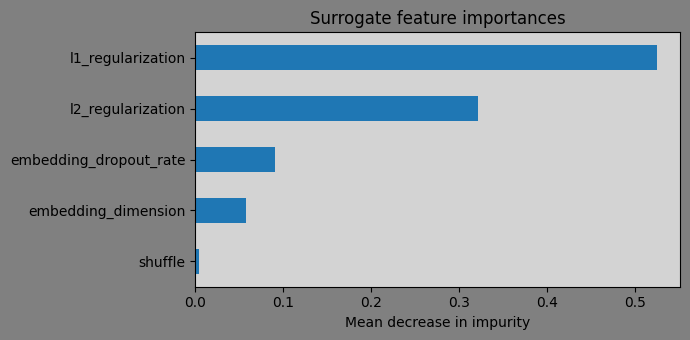

In [48]:
# Test set: runs at or across either performance cliff (raw scale — pipeline handles log transform)
mask_cliff = (
    full_dataframe["l1_regularization"].is_in([1e-7, 1e-6])
    | full_dataframe["l2_regularization"].is_in([1e-6, 1e-5])
)

train_dataframe = full_dataframe.filter(~mask_cliff)
test_dataframe  = full_dataframe.filter(mask_cliff)

train_features = train_dataframe.select(feature_names).to_numpy()
train_target   = train_dataframe[target_metric].to_numpy()
test_features  = test_dataframe.select(feature_names).to_numpy()
test_target    = test_dataframe[target_metric].to_numpy()

print(f"Train size: {len(train_dataframe):,}  |  Test size (cliff runs): {len(test_dataframe):,}")
print(f"Test target range: [{test_target.min():.4f}, {test_target.max():.4f}]")
print()

surrogate_eval = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=1024,
        max_features="sqrt",
        max_samples=0.1,
        min_samples_leaf=1,
        oob_score=False,
        n_jobs=-1,
        random_state=42,
    )),
])
surrogate_eval.fit(train_features, train_target)
predicted_target = surrogate_eval.predict(test_features)

print(f"Held-out R²:  {r2_score(test_target, predicted_target):.4f}")
print(f"Held-out MAE: {mean_absolute_error(test_target, predicted_target):.4f}")

# Feature importance plot (from the full-data surrogate)
fig, ax = plt.subplots(figsize=(7, 3.5))
importances = pd.Series(surrogate_eval.named_steps["rf"].feature_importances_, index=feature_names).sort_values(ascending=True)
importances.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Surrogate feature importances")

plt.tight_layout()
plt.show()

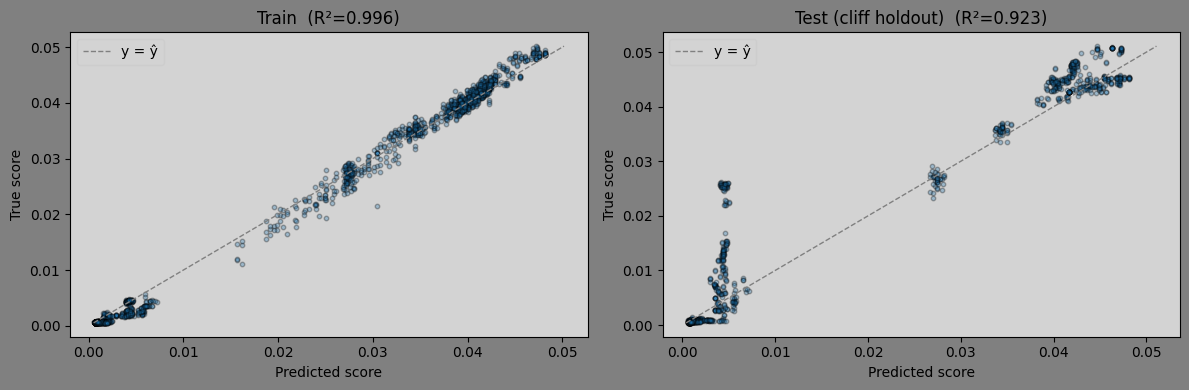

In [49]:
train_prediction = surrogate_eval.predict(train_features)
test_prediction  = surrogate_eval.predict(test_features)

axes: List[plt.Axes]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ground_truth, prediction, label in [
    (axes[0], train_target, train_prediction, "Train"),
    (axes[1], test_target,  test_prediction,  "Test (cliff holdout)"),
]:
    ax.scatter(prediction, ground_truth, alpha=0.3, s=10)
    lo = min(ground_truth.min(), prediction.min())
    hi = max(ground_truth.max(), prediction.max())
    ax.plot([lo, hi], [lo, hi], "--", linewidth=1, label="y = ŷ", color="grey")
    ax.set_xlabel("Predicted score")
    ax.set_ylabel("True score")
    ax.set_title(f"{label}  (R²={r2_score(ground_truth, prediction):.3f})")
    ax.legend()

plt.tight_layout()
plt.show()

### μ̂ and σ̂ Distributions — Train vs. Test

Comparing the predicted mean (μ̂) and uncertainty (σ̂) distributions across the train and test splits.

- **Similar μ̂ distributions** → the surrogate generalises rather than memorising
- **Higher σ̂ on test** → the model correctly signals more uncertainty on less-seen configurations

> **Note:** The test set here is the **cliff holdout** (l1=1e-6/1e-7, l2=1e-5/1e-6) — these are runs held out from fitting but still in well-explored regions. The σ̂ separation is naturally smaller than the full unexplored grid check below (see **σ̂ Validation** section).

Train — μ̂: 0.0230 ± 0.0184   σ̂: 0.0039 ± 0.0021   UCB: 0.0385 ± 0.0203
Test  — μ̂: 0.0172 ± 0.0191   σ̂: 0.0055 ± 0.0025   UCB: 0.0392 ± 0.0232
σ̂ ratio (test / train): 1.43x  (cliff holdout — expect smaller than full unexplored grid)


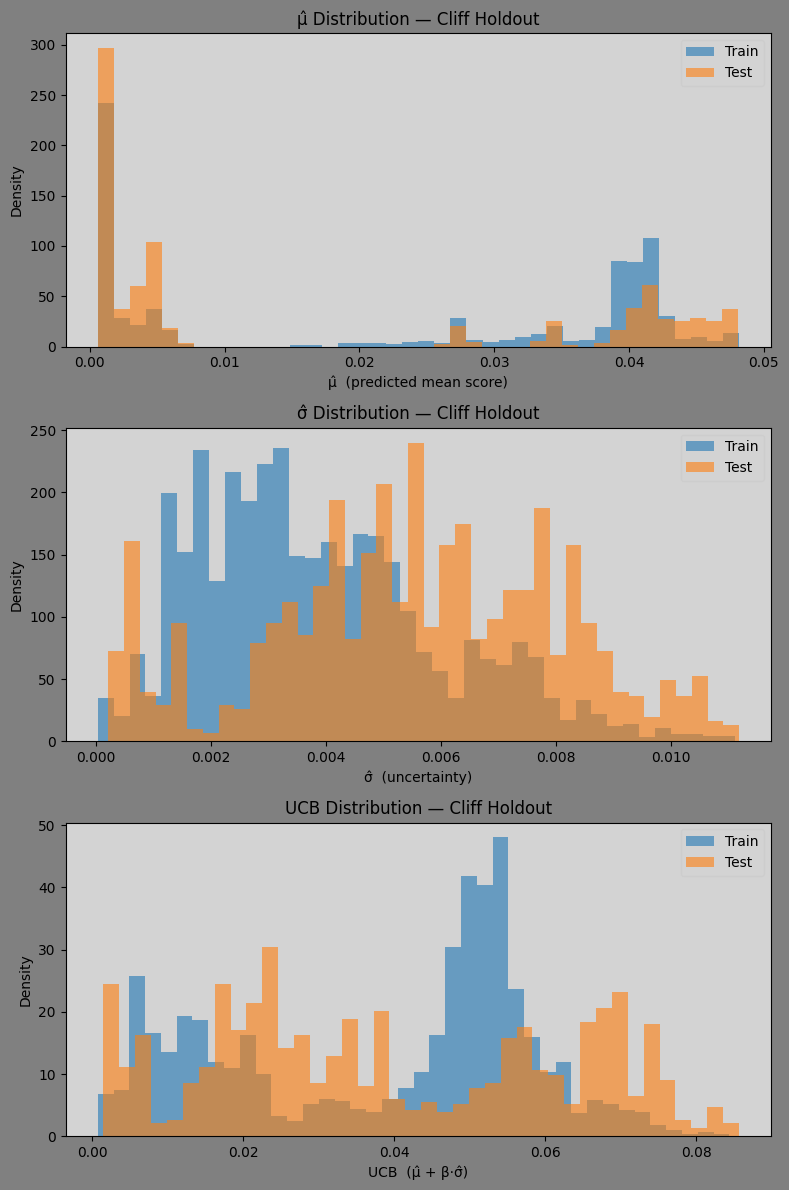

In [50]:
# Compute per-tree predictions for train and test splits to get µ̂, σ̂, and UCB
rf_eval = surrogate_eval.named_steps["rf"]
log_train = surrogate_eval.named_steps["log_reg"].transform(train_features)
log_test  = surrogate_eval.named_steps["log_reg"].transform(test_features)
train_tree_predictions = np.stack([tree.predict(log_train) for tree in rf_eval.estimators_], axis=0)
test_tree_predictions  = np.stack([tree.predict(log_test)  for tree in rf_eval.estimators_], axis=0)

mu_train    = train_tree_predictions.mean(axis=0)
sigma_train = train_tree_predictions.std(axis=0)
mu_test     = test_tree_predictions.mean(axis=0)
sigma_test  = test_tree_predictions.std(axis=0)
ucb_train   = mu_train + beta * sigma_train
ucb_test    = mu_test  + beta * sigma_test

sigma_ratio = sigma_test.mean() / sigma_train.mean()
print(f"Train — μ̂: {mu_train.mean():.4f} ± {mu_train.std():.4f}   σ̂: {sigma_train.mean():.4f} ± {sigma_train.std():.4f}   UCB: {ucb_train.mean():.4f} ± {ucb_train.std():.4f}")
print(f"Test  — μ̂: {mu_test.mean():.4f} ± {mu_test.std():.4f}   σ̂: {sigma_test.mean():.4f} ± {sigma_test.std():.4f}   UCB: {ucb_test.mean():.4f} ± {ucb_test.std():.4f}")
print(f"σ̂ ratio (test / train): {sigma_ratio:.2f}x  (cliff holdout — expect smaller than full unexplored grid)")

# Histogram comparison — μ̂, σ̂, and UCB side by side
axes: List[plt.Axes]
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# µ̂ distribution
axes[0].hist(mu_train, bins=40, alpha=0.6, density=True, label="Train")
axes[0].hist(mu_test,  bins=40, alpha=0.6, density=True, label="Test")
axes[0].set_xlabel("μ̂  (predicted mean score)")
axes[0].set_ylabel("Density")
axes[0].set_title("μ̂ Distribution — Cliff Holdout")
axes[0].legend()

# σ̂ distribution
axes[1].hist(sigma_train, bins=40, alpha=0.6, density=True, label="Train")
axes[1].hist(sigma_test,  bins=40, alpha=0.6, density=True, label="Test")
axes[1].set_xlabel("σ̂  (uncertainty)")
axes[1].set_ylabel("Density")
axes[1].set_title("σ̂ Distribution — Cliff Holdout")
axes[1].legend()

# UCB distribution
axes[2].hist(ucb_train, bins=40, alpha=0.6, density=True, label="Train")
axes[2].hist(ucb_test,  bins=40, alpha=0.6, density=True, label="Test")
axes[2].set_xlabel("UCB  (μ̂ + β·σ̂)")
axes[2].set_ylabel("Density")
axes[2].set_title("UCB Distribution — Cliff Holdout")
axes[2].legend()

plt.tight_layout()
plt.show()

## Full Parameter Space — Explored vs. Unexplored

Enumerate every combination in `PARAM_SPACE`, then label each cell as explored (at least one completed run exists) or unexplored. The surrogate will be applied to the unexplored cells.

In [51]:
# Build the full grid as a DataFrame
all_combinations = list(itertools.product(*parameter_space.values()))
full_grid = pl.DataFrame(
    {col: [row[i] for row in all_combinations] for i, col in enumerate(feature_names)}
)

# Align dtypes with full_dataframe (shuffle is cast to f64 there)
full_grid = full_grid.with_columns(pl.col("shuffle").cast(pl.Float64))

# Aggregate explored runs: take the mean observed score per unique config
explored_dataframe = (
    full_dataframe
    .group_by(feature_names)
    .agg(pl.col(target_metric).mean().alias(f"observed_{target_metric}"))
)

# Tag each grid cell as explored or not
explored_keys = set(
    tuple(row) for row in explored_dataframe.select(feature_names).to_numpy().tolist()
)
full_grid = full_grid.with_columns(
    pl.struct(feature_names)
    .map_elements(lambda s: tuple(s[c] for c in feature_names) in explored_keys, return_dtype=pl.Boolean)
    .alias("explored")
)

# Join observed metric onto the grid (null for unexplored cells)
full_grid = full_grid.join(explored_dataframe, on=feature_names, how="left")

n_explored   = full_grid["explored"].sum()
n_unexplored = len(full_grid) - n_explored
coverage_pct = 100 * n_explored / len(full_grid)

print(f"Total cells:  {len(full_grid):,}")
print(f"Explored:     {n_explored:,}  ({coverage_pct:.2f}%)")
print(f"Unexplored:   {n_unexplored:,}")

# Show top 5 + "..." + bottom 5 preview
import pandas as pd

display_cols = feature_names + ["explored", f"observed_{target_metric}"]
grid_preview = full_grid.select(display_cols).to_pandas()
ellipsis = pd.DataFrame([{c: "…" for c in display_cols}])
grid_preview = pd.concat([grid_preview.head(5), ellipsis, grid_preview.tail(5)], ignore_index=True)

data_preview_styled(
    grid_preview,
    caption=f"Grid preview — {len(full_grid):,} total cells, {n_explored:,} explored ({coverage_pct:.2f}%)",
    max_rows=11,
)

Total cells:  20,000
Explored:     1,516  (7.58%)
Unexplored:   18,484


,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,explored,observed_target
0,2,0.000000,0.000000,0.000000,0.000000,True,0.028197
1,2,0.000000,0.000000,0.000000,0.100000,True,0.023229
2,2,0.000000,0.000000,0.000000,0.200000,True,0.022076
3,2,0.000000,0.000000,0.000000,0.300000,True,0.022114
4,2,0.000000,0.000000,0.000000,0.400000,True,0.021016
5,…,…,…,…,…,…,…
6,1024,1.000000,0.010000,0.010000,0.500000,False,nan
7,1024,1.000000,0.010000,0.010000,0.600000,False,nan
8,1024,1.000000,0.010000,0.010000,0.700000,False,nan
9,1024,1.000000,0.010000,0.010000,0.800000,False,nan


In [52]:
# Predict μ̂ and σ̂ for the full grid
full_grid_features = full_grid.select(feature_names).to_numpy()

surrogate_forrest = surrogate.named_steps["rf"]
full_grid_features_log = surrogate.named_steps["log_reg"].transform(full_grid_features)
tree_predictions = np.stack([tree.predict(full_grid_features_log) for tree in surrogate_forrest.estimators_], axis=0)  # (n_trees, n_cells)
mu_hat = tree_predictions.mean(axis=0)
sigma_hat = tree_predictions.std(axis=0)

full_grid = full_grid.with_columns([
    pl.Series("mu_hat",    mu_hat),
    pl.Series("sigma_hat", sigma_hat),
    pl.Series("ucb",       mu_hat + beta * sigma_hat),
])

unexplored_dataframe = full_grid.filter(~pl.col("explored"))

print(f"Predictions computed for {len(full_grid):,} cells ({len(unexplored_dataframe):,} unexplored)")

data_preview_styled(
    full_grid.select("explored", "mu_hat", "sigma_hat", "ucb").describe().to_pandas(),
    caption="Summary statistics — μ̂, σ̂, and UCB across the full parameter grid",
)

Predictions computed for 20,000 cells (18,484 unexplored)


,statistic,explored,mu_hat,sigma_hat,ucb
0,count,20000,20000,20000,20000
1,null_count,0,0,0,0
2,mean,0.0758,0.0131982,0.00702964,0.0413167
3,std,nan,0.015862,0.00307888,0.01939
4,min,0,0.000577975,2.69648e-05,0.000740538
5,25%,nan,0.00194975,0.00483416,0.0256609
6,50%,nan,0.00366221,0.00700145,0.0392465
7,75%,nan,0.0268912,0.00887645,0.0570396
8,max,1,0.0497096,0.0205886,0.101334


In [53]:
# Show full grid with observed metric and surrogate predictions (top 5 + "..." + bottom 5 by UCB)
display_cols = feature_names + ["explored", f"observed_{target_metric}", "mu_hat", "sigma_hat", "ucb"]
sorted_grid = (
    full_grid
    .with_columns(
        pl.col("l1_regularization").cast(pl.Utf8),
        pl.col("l2_regularization").cast(pl.Utf8),
    )
    .sort("ucb", descending=True)
    .select(display_cols)
    .to_pandas()
)

ellipsis = pd.DataFrame([{c: "…" for c in display_cols}])
preview = pd.concat([sorted_grid.head(5), ellipsis, sorted_grid.tail(5)], ignore_index=True)

data_preview_styled(
    preview,
    caption="Grid sorted by UCB (descending) — top 5 and bottom 5",
    max_rows=11,
)

,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,explored,observed_target,mu_hat,sigma_hat,ucb
0,512,0.000000,1e-7,1e-7,0.900000,False,nan,0.018980,0.020589,0.101334
1,1024,0.000000,1e-7,1e-7,0.900000,False,nan,0.019075,0.020417,0.100744
2,512,1.000000,1e-7,1e-7,0.900000,False,nan,0.019101,0.020385,0.100642
3,128,0.000000,1e-7,1e-7,0.900000,False,nan,0.018455,0.020519,0.100533
4,256,0.000000,1e-7,1e-7,0.900000,False,nan,0.018565,0.020477,0.100472
5,…,…,…,…,…,…,…,…,…,…
6,64,0.000000,0.0001,1e-7,0.000000,True,0.000557,0.000585,0.000044,0.000761
7,256,0.000000,0.01,0.0,0.000000,True,0.000628,0.000633,0.000032,0.000760
8,128,0.000000,0.001,0.0,0.000000,True,0.000629,0.000626,0.000030,0.000744
9,128,0.000000,0.01,0.0,0.000000,True,0.000646,0.000634,0.000027,0.000742


### σ̂ Validation — Explored vs. Unexplored Cells

Verify the acquisition surrogate has higher uncertainty on unexplored cells than explored ones. This confirms the tree diversity strategy (10% samples, sqrt features, leaf=1) is working as intended.

- **Target:** mean σ̂ on unexplored cells ≥ 1.5× mean σ̂ on explored cells
- **If below 1.5×:** the acquisition RF needs higher tree diversity (reduce `max_samples`, increase `n_estimators`, or reduce `min_samples_leaf`)

Explored cells:   μ̂ = 0.019721 ± 0.018784   σ̂ = 0.004276 ± 0.002227   UCB = 0.036826 ± 0.020783
Unexplored cells: μ̂ = 0.012663 ± 0.015476   σ̂ = 0.007255 ± 0.003029   UCB = 0.041685 ± 0.019224
σ̂ ratio (unexplored / explored): 1.70x
Target: ≥ 1.5x  →  ✓ PASS


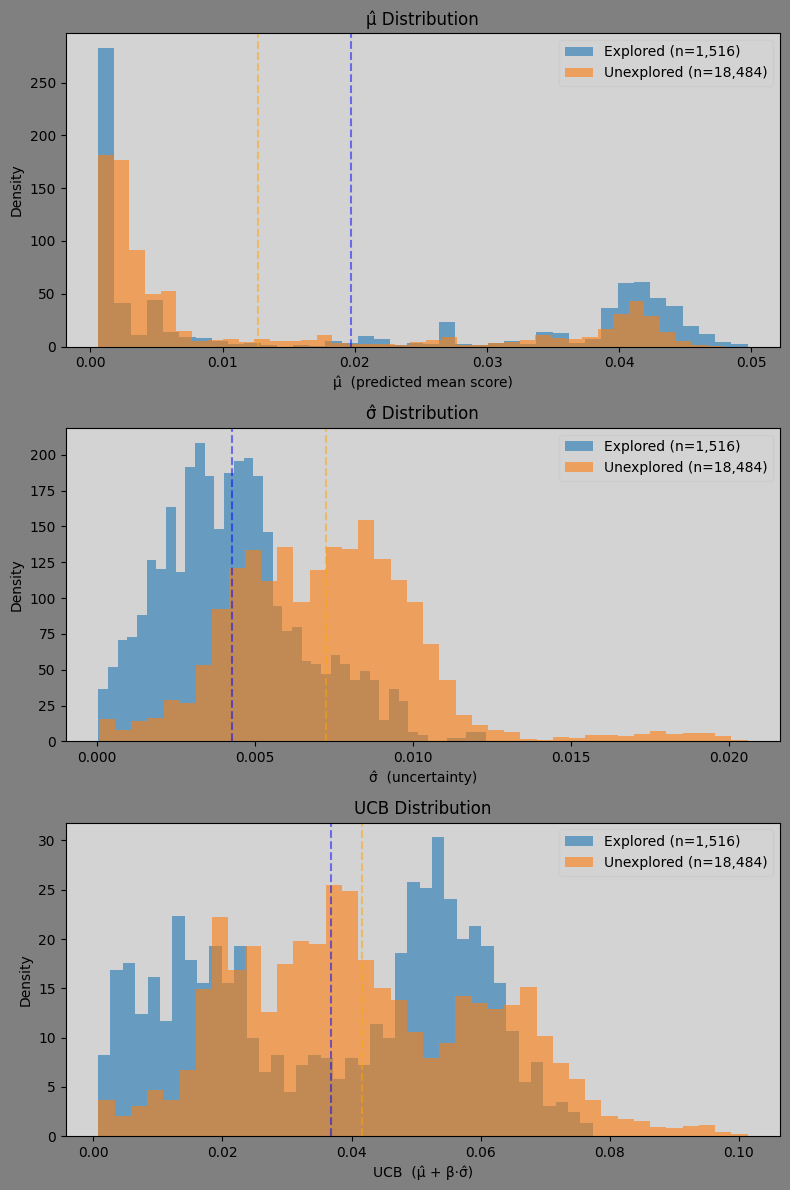

In [54]:
# Compute μ̂, σ̂, and UCB for explored vs unexplored cells across the full grid
explored_mu = full_grid.filter(pl.col("explored"))["mu_hat"]
unexplored_mu = full_grid.filter(~pl.col("explored"))["mu_hat"]
explored_sigma = full_grid.filter(pl.col("explored"))["sigma_hat"]
unexplored_sigma = full_grid.filter(~pl.col("explored"))["sigma_hat"]
explored_ucb = full_grid.filter(pl.col("explored"))["ucb"]
unexplored_ucb = full_grid.filter(~pl.col("explored"))["ucb"]

explored_mu_vector = explored_mu.to_numpy()
unexplored_mu_vector = unexplored_mu.to_numpy()
explored_sigma_vector = explored_sigma.to_numpy()
unexplored_sigma_vector = unexplored_sigma.to_numpy()
explored_ucb_vector = explored_ucb.to_numpy()
unexplored_ucb_vector = unexplored_ucb.to_numpy()

sigma_ratio = unexplored_sigma_vector.mean() / explored_sigma_vector.mean() if explored_sigma_vector.mean() > 0 else float('inf')

print(f"Explored cells:   μ̂ = {explored_mu_vector.mean():.6f} ± {explored_mu_vector.std():.6f}   σ̂ = {explored_sigma_vector.mean():.6f} ± {explored_sigma_vector.std():.6f}   UCB = {explored_ucb_vector.mean():.6f} ± {explored_ucb_vector.std():.6f}")
print(f"Unexplored cells: μ̂ = {unexplored_mu_vector.mean():.6f} ± {unexplored_mu_vector.std():.6f}   σ̂ = {unexplored_sigma_vector.mean():.6f} ± {unexplored_sigma_vector.std():.6f}   UCB = {unexplored_ucb_vector.mean():.6f} ± {unexplored_ucb_vector.std():.6f}")
print(f"σ̂ ratio (unexplored / explored): {sigma_ratio:.2f}x")
print(f"Target: ≥ 1.5x  →  {'✓ PASS' if sigma_ratio >= 1.5 else '✗ FAIL — consider adjusting hyperparams'}")

# Histogram comparison — μ̂, σ̂, and UCB side by side
axes: List[plt.Axes]
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# μ̂ distribution
axes[0].hist(explored_mu_vector, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_mu_vector):,})")
axes[0].hist(unexplored_mu_vector, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_mu_vector):,})")
axes[0].axvline(explored_mu_vector.mean(), color='blue', linestyle='--', alpha=0.5)
axes[0].axvline(unexplored_mu_vector.mean(), color='orange', linestyle='--', alpha=0.5)
axes[0].set_xlabel("μ̂  (predicted mean score)")
axes[0].set_ylabel("Density")
axes[0].set_title("μ̂ Distribution")
axes[0].legend()

# σ̂ distribution
axes[1].hist(explored_sigma_vector, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_sigma_vector):,})")
axes[1].hist(unexplored_sigma_vector, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_sigma_vector):,})")
axes[1].axvline(explored_sigma_vector.mean(), color='blue', linestyle='--', alpha=0.5)
axes[1].axvline(unexplored_sigma_vector.mean(), color='orange', linestyle='--', alpha=0.5)
axes[1].set_xlabel("σ̂  (uncertainty)")
axes[1].set_ylabel("Density")
axes[1].set_title("σ̂ Distribution")
axes[1].legend()

# UCB distribution
axes[2].hist(explored_ucb_vector, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_ucb_vector):,})")
axes[2].hist(unexplored_ucb_vector, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_ucb_vector):,})")
axes[2].axvline(explored_ucb_vector.mean(), color='blue', linestyle='--', alpha=0.5)
axes[2].axvline(unexplored_ucb_vector.mean(), color='orange', linestyle='--', alpha=0.5)
axes[2].set_xlabel("UCB  (μ̂ + β·σ̂)")
axes[2].set_ylabel("Density")
axes[2].set_title("UCB Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

## Exploration Saturation Metric (ESM)

$$\text{ESM} = \frac{\mu_{\text{best, observed}}}{\hat{\mu}_{\text{max}} + \beta \cdot \hat{\sigma}_{\text{max}}} \times 100\%$$

- **Numerator** — best score actually seen in completed runs
- **Denominator** — max UCB across the entire grid (explored + unexplored)

A higher ESM means the sub-space is more saturated. 99.99% (4 nines) is the suggested stop threshold.

In [16]:
mu_best_observed = explored_dataframe[f"observed_{target_metric}"].max()

# UCB of the best cell across the entire grid (explored + unexplored)
best_ucb_idx  = full_grid["ucb"].arg_max()
mu_hat_max    = full_grid["mu_hat"][best_ucb_idx]
sigma_hat_max = full_grid["sigma_hat"][best_ucb_idx]
ucb_max       = mu_hat_max + beta * sigma_hat_max

esm = (mu_best_observed / ucb_max) * 100

# Count "nines" after the decimal
nines = 0
while (esm / 100) >= 9 * (10 ** (-nines - 1)) + (1 - 10 ** (-nines)):
    nines += 1
    if nines > 10:
        break

print(f"Best observed score (μ_best): {mu_best_observed:.6f}")
print(f"Best grid UCB:        μ̂={mu_hat_max:.6f}  σ̂={sigma_hat_max:.6f}  UCB={ucb_max:.6f}")
print()
print(f"ESM = {esm:.6f}%  ({nines} nines)")

thresholds = [(99.99, "4 nines — essentially saturated, move on"),
              (99.9,  "3 nines — marginal gain remaining"),
              (99.0,  "2 nines — modest gain remaining"),
              (90.0,  "1 nine  — substantial gain likely remaining")]
for threshold, label in thresholds:
    if esm >= threshold:
        print(f"  → {label}")
        break
else:
    print("  → Below 90% — early exploration stage")


Best observed score (μ_best): 0.050782
Best grid UCB:        μ̂=0.047743  σ̂=0.006570  UCB=0.054313

ESM = 93.498064%  (1 nines)
  → 1 nine  — substantial gain likely remaining


## Coverage at Percentile

$$\text{Coverage}_{p} = \frac{|\{x \in \text{explored} : \hat{\mu}(x) \geq p\text{-th percentile}\}|}{|\{x \in \text{all} : \hat{\mu}(x) \geq p\text{-th percentile}\}|}$$

Using p=75: *"what fraction of the top-25% predicted configurations have been tried?"*

In [17]:
def coverage_at_percentile(grid: pl.DataFrame, p: float = 75.0) -> float:
    """Fraction of top-(100-p)% predicted configs that have been explored."""
    threshold = np.percentile(grid["mu_hat"].to_numpy(), p)
    top_cells = grid.filter(pl.col("mu_hat") >= threshold)
    return 100.0 * top_cells["explored"].sum() / len(top_cells)

for p in [50, 75, 90, 95]:
    cov = coverage_at_percentile(full_grid, p)
    print(f"Coverage at p={p:2d}  (top {100-p:2d}% predicted configs):  {cov:.2f}%")


Coverage at p=50  (top 50% predicted configs):  9.00%
Coverage at p=75  (top 25% predicted configs):  13.14%
Coverage at p=90  (top 10% predicted configs):  16.75%
Coverage at p=95  (top  5% predicted configs):  22.40%


## Stop Condition

Stop exploring this sub-space when **both** hold:
- ESM ≥ 99.9% (3 nines)
- Coverage at p=75 ≥ 80%

In [18]:
ESM_STOP_THRESHOLD      = 99.9   # 3 nines
COVERAGE_STOP_THRESHOLD = 80.0   # percent
COVERAGE_PERCENTILE     = 75

coverage_75 = coverage_at_percentile(full_grid, COVERAGE_PERCENTILE)

esm_met      = esm >= ESM_STOP_THRESHOLD
coverage_met = coverage_75 >= COVERAGE_STOP_THRESHOLD
should_stop  = esm_met and coverage_met

print("=" * 50)
print(f"  ESM:          {esm:.4f}%   (threshold ≥ {ESM_STOP_THRESHOLD}%)  {'✓' if esm_met else '✗'}")
print(f"  Coverage@75:  {coverage_75:.2f}%    (threshold ≥ {COVERAGE_STOP_THRESHOLD}%)  {'✓' if coverage_met else '✗'}")
print("=" * 50)
print(f"  → {'STOP — sub-space saturated.' if should_stop else 'CONTINUE exploration.'}")
print("=" * 50)


  ESM:          93.4981%   (threshold ≥ 99.9%)  ✗
  Coverage@75:  13.14%    (threshold ≥ 80.0%)  ✗
  → CONTINUE exploration.
